In [226]:
from langgraph.graph.message import MessagesState
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, Literal, Optional
from pydantic import BaseModel, EmailStr, Field
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.utilities import SQLDatabase
from langchain_groq import ChatGroq
from email.message import EmailMessage
import smtplib
from dotenv import load_dotenv
import os
load_dotenv()

True

In [227]:
pwd = os.getenv('gmail_password')

In [228]:
@tool
def send_sales_email(recipient_email: str, subject: str, body: str):
    """
    Sends a professional sales email to a specific recipient.
    Use this only after the SQL query results are processed into a pitch.
    """
    msg = EmailMessage()
    msg.set_content(body)
    msg['Subject'] = subject
    msg['To'] = recipient_email
    msg['From'] = "akshatsharma5877@gmail.com"

    try:
        with smtplib.SMTP_SSL('smtp.gmail.com', 465) as smtp:
            smtp.login("akshatsharma5877@gmail.com", pwd)
            smtp.send_message(msg)
        return "Email sent successfully!"
    except Exception as e:
        return f"Failed to send email: {str(e)}"

In [229]:
db = SQLDatabase.from_uri("sqlite:///Chinook.db", sample_rows_in_table_info=0)

def get_schema():
    return db.get_table_info()

@tool
def run_query(query):
    """This function takes the query as input and execute the command and return results from DB"""
    print(f"Query being run: {query}\n")
    return db.run(query)

In [230]:
tools = [run_query]

In [231]:
class SQLWorkflowState(MessagesState):
    generated_sql: str 
    reason_behind_generated_sql: str
    feedback: str 
    retry_count: int
    result: str
    intent: str
    reason_for_intent: str
    email: EmailStr
    email_subject: str
    email_body: str
    email_send: str

In [232]:
class IntentStructure(BaseModel):
    decision: Literal["Ambiguous", "Unsafe", "Valid"]
    explaination: str
    email: Optional[EmailStr]

def find_intent(state: SQLWorkflowState):
    systemmessage = """Role: You are the Lead Database Administrator and Security Gatekeeper (Supervisor Agent). Your sole objective is to classify incoming natural language queries into one of three operational categories to ensure system safety and data integrity.
        one more task that is assigned to you is that, you have to analyze the user message and check if the user wants to send the email to someone (user write a valid email address), then return a email address too
        Operational Schema (Decision Logic):

        Ambiguous: >    - The user's intent is unclear or lacks sufficient context (e.g., "Show me the data").

        The request references entities or metrics not typically found in a relational database.

        The question is conversational and contains no data-retrieval intent.

        question uses pronoun instead of specific keyword, like "car of that segment", "most expensive car of all those company"

        Unsafe:

        The request implies any Data Manipulation Language (DML), Data Control Language (DCL) or Data Definition Language (DDL) operations.

        Keywords/Intents: DELETE, UPDATE, INSERT, DROP, TRUNCATE, ALTER, GRANT, REVOKE, CREATE.

        Any attempt to modify records, schemas, or permissions.

        Valid:

        The request is a clear, read-only analytical question.

        The request focuses on data retrieval, aggregation, or reporting.

        Keywords/Intents: SELECT, COUNT, SUM, AVERAGE, GROUP BY, JOIN.

        Constraints:

        You must respond with exactly one word: Ambiguous, Unsafe, or Valid.

        Do not provide explanations, markdown formatting, or preamble.

        When in doubt between Ambiguous and Valid, choose Ambiguous to prioritize accuracy.

        Examples:

        "What was the total revenue in Q3?" -> Valid

        "Delete all users who haven't logged in." -> Unsafe

        "Check the thing for me." -> Ambiguous

        also you need to provide an small one liner description why you those perticular decision

        if you find a email that user want to send a generated query result, then return that email too
    """

    model = ChatGroq(
        model_name='openai/gpt-oss-safeguard-20b',
        temperature=0.1
        )
    
    structued_model = model.with_structured_output(IntentStructure)

    chat_template = ChatPromptTemplate.from_messages(
        [("system", systemmessage),
         ("human", "{question}")]  
    )

    chain = chat_template | structued_model

    result : IntentStructure = chain.invoke(
        {
            'question' : state['messages']
        }
    )

    print(f'the intent is - {result.decision} and reasoning behind this is - {result.explaination}')

    return {"intent" : result.decision, 'email' : result.email}

In [233]:
def decision_router(state: SQLWorkflowState):
    if state['intent'] == 'Ambiguous':
        return 'Ambiguous'
    elif state['intent'] == 'Unsafe':
        return 'Unsafe'
    else:
        return 'Valid'

In [234]:
def Ambiguous_Node(state: SQLWorkflowState):
    response = f"The question asked is ambiguous, because of {state['reason_for_intent']}"
    return {'messages' : response}

In [235]:
def Unsafe_Node(state: SQLWorkflowState):
    response = f"Cannot generate and execute the SQL as it involve high stake decision because of following reason {state['reason_for_intent']}"
    return {"messages" : response}

In [236]:
class SQLStructure(BaseModel):
    SQL_query: str
    explaination : str

def SQL_Generator(state: SQLWorkflowState):
    systemprompt = """You are a State-of-art personality in SQL query writing, given this schema below write a sql query for given question, if the feedback is given then create response based on the feedback given to you"""

    prompt = ChatPromptTemplate.from_messages(
        [
            ('system', systemprompt),
            ('human', 'Here is DATABASE SCHEMA \n\n {schema} \n\n and here is the question for which you need to write SQL query {question}')
        ]
    )

    model = ChatGroq(
        model_name='openai/gpt-oss-safeguard-20b',
        temperature=0.1
        )
    
    structuredmodel = model.with_structured_output(SQLStructure)

    chain = prompt | structuredmodel

    question = ''

    if state.get('feedback'):
        question += f"\nYour previous query failed, fix it based on this : {state['feedback']}"
    
    question += f"\n\n question is {state['messages']}"

    response: SQLStructure = chain.invoke(
        {
            'schema' : get_schema(),
            'question' : question
        }
    )

    current_retries = state.get('retry_count', 0)

    return {'reason_behind_generated_sql': response.explaination, 'generated_sql': response.SQL_query, 'retry_count' : current_retries + 1}

In [244]:
def Evaluator(state: SQLWorkflowState):
    sql = state['generated_sql']

    if any(word in sql.upper().split() for word in ['CREATE', 'DROP', 'ALTER', 'TRUNCATE', 'DELETE', 'INSERT', 'UPDATE', 'GRANT', 'REVOKE']):
        return {'feedback': f"Safety violation: command you have written is -> {sql} \n  But you cannot write the query with the DML,DDL, DCL commands, re-write using SELECT"}
    
    try:
        result = run_query.invoke(sql)
    except Exception as e:
        return {'feedback' : f'There is error while executing this SQL command \n Error - {e}'}
    else:
        if len(result) > 500:
            return {
                'feedback' : f"the query returned too much data. To prevent server overload, rewrite the query to return fewer rows with strictly the LIMIT clause with only 10 rows, no matter how many rows, the user is asking."
            }
        return {'feedback' : None, 'result' : result}

In [245]:
def should_we_loop(state: SQLWorkflowState):
    if state['feedback'] and state['retry_count'] < 3:
        return 'rewrite'
    elif state.get('email', ''):
        return 'sales_agent'
    else:
        return 'back'

In [246]:
class EmailDraft(BaseModel):
    subject: str = Field(description="A catchy, professional subject line")
    body: str = Field(description="The full email body based on SQL data and AVA's personality")
    
def sales_node(state: SQLWorkflowState):
    model = ChatGroq(
        model_name='openai/gpt-oss-safeguard-20b',
        temperature=0.1
        )
    
    structured_model = model.with_structured_output(EmailDraft)

    system_prompt = f"""
    You are AVA's Sales Specialist. 
    Analyze these SQL results: {state['result']}
    Based on the user's request: {state['messages']}
    
    Your task:
    - Extract the recipient email.
    - Draft a high-conversion email in AVA's witty personality.
    - the Draft created will be the final one, and hence don't include anything like placeholder or anything that makes user feels that it is generated by bot
    - Return the result as a structured JSON object.
    """
    

    draft : EmailDraft = structured_model.invoke(system_prompt)

    return {
        "email_subject": draft.subject,
        "email_body" : draft.body
    }

In [247]:
def email_sender_node(state: SQLWorkflowState):
    result = send_sales_email.invoke(
        {
          'recipient_email' : state['email'],
          'subject' :  state['email_subject'],
          'body' : state['email_body']
        }
    )
    
    return {'email_send' : result}

In [ ]:
# tool_node = ToolNode(tools)

graph_builder = StateGraph(SQLWorkflowState)

graph_builder.add_node("find_intent", find_intent)
graph_builder.add_node('Ambiguous_Node', Ambiguous_Node)
graph_builder.add_node('Unsafe_Node', Unsafe_Node)
graph_builder.add_node('SQL_Generator', SQL_Generator)
graph_builder.add_node('Evaluator', Evaluator)
graph_builder.add_node("sales_node", sales_node)
graph_builder.add_node("email_sender_node", email_sender_node)

graph_builder.add_edge(START, 'find_intent')
graph_builder.add_conditional_edges('find_intent', decision_router, {'Ambiguous': 'Ambiguous_Node', 'Unsafe': 'Unsafe_Node', 'Valid' : 'SQL_Generator'})
graph_builder.add_edge('SQL_Generator', 'Evaluator')
graph_builder.add_conditional_edges('Evaluator', should_we_loop, {
    "rewrite" : "SQL_Generator",
    "sales_agent" : 'sales_node',
    'back' : END
})
graph_builder.add_edge('sales_node', 'email_sender_node')

graph_builder.add_edge("email_sender_node", END)

graph = graph_builder.compile()

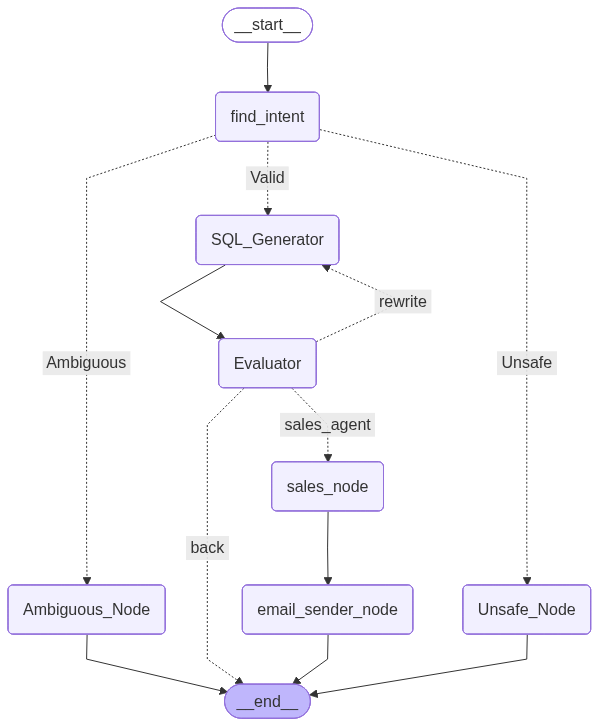

In [249]:
graph

In [250]:
graph.invoke({"messages" : 'top 70 artist based on number of songs/album and do a marketing campaign to as3248@srmist.edu.in'})

the intent is - Valid and reasoning behind this is - User asks for a read‑only top‑70 artist list and provides an email address for a marketing campaign.
Query being run: SELECT a.ArtistId, a.Name, COUNT(t.TrackId) AS TotalTracks
FROM Artist a
JOIN Album al ON al.ArtistId = a.ArtistId
JOIN Track t ON t.AlbumId = al.AlbumId
GROUP BY a.ArtistId, a.Name
ORDER BY TotalTracks DESC
LIMIT 70;

Query being run: SELECT a.ArtistId, a.Name, COUNT(t.TrackId) AS TotalTracks, COUNT(DISTINCT al.AlbumId) AS TotalAlbums
FROM Artist a
LEFT JOIN Album al ON al.ArtistId = a.ArtistId
LEFT JOIN Track t ON t.AlbumId = al.AlbumId
GROUP BY a.ArtistId, a.Name
ORDER BY TotalTracks DESC
LIMIT 10;



{'messages': [HumanMessage(content='top 70 artist based on number of songs/album and do a marketing campaign to as3248@srmist.edu.in', additional_kwargs={}, response_metadata={}, id='1d803ae9-c4bb-4e2b-94ae-b2b9590be555')],
 'generated_sql': 'SELECT a.ArtistId, a.Name, COUNT(t.TrackId) AS TotalTracks, COUNT(DISTINCT al.AlbumId) AS TotalAlbums\nFROM Artist a\nLEFT JOIN Album al ON al.ArtistId = a.ArtistId\nLEFT JOIN Track t ON t.AlbumId = al.AlbumId\nGROUP BY a.ArtistId, a.Name\nORDER BY TotalTracks DESC\nLIMIT 10;',
 'reason_behind_generated_sql': 'This query lists the top 10 artists ranked by the total number of tracks they have released. It also shows how many distinct albums each artist has. The LIMIT clause ensures only 10 rows are returned, preventing server overload. The marketing email address can be used separately to notify the campaign team.',
 'feedback': None,
 'retry_count': 2,
 'result': "[(90, 'Iron Maiden', 213, 21), (150, 'U2', 135, 10), (22, 'Led Zeppelin', 114, 14), 